# Country Metrics Clustering Analysis

## Project Objective

The objective of this notebook is to perform unsupervised clustering on a country-level socio-economic dataset.

This notebook follows the required assignment workflow:

1. Install and import required libraries .
2. Upload and load the country metrics CSV dataset.
3. Clean the dataset by fixing column names, removing duplicates, converting values to numeric format, and imputing missing values.
4. Remove the country identifier column and scale the continuous features using `StandardScaler`.
5. Use the Elbow Method for K-Means cluster optimization.
6. Train a baseline K-Means model with `best_k = 3`.
7. Evaluate clustering stability using `silhouette_score`.
8. Build a comparative DBSCAN clustering model.
9. Reduce high-dimensional data into 2D using PCA and visualize country segments.
10. Write socio-economic observations about mortality, economic strength, and low-development clusters.

## Section 1: Import Required Libraries

Import the Python libraries required for data analysis, preprocessing, clustering, dimensionality reduction, and visualization.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

## Section 2: Load the Dataset

Read the uploaded CSV file using pandas and display the first few records.

In [3]:
df = pd.read_csv("Country-data.csv")

print("Dataset loaded successfully.")
print("Shape of dataset:", df.shape)

df.head()

Dataset loaded successfully.
Shape of dataset: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## Section 3: Initial Dataset Information

Check column names, data types, missing values, and duplicate records before cleaning.

In [4]:
print("Column Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Records:")
print(df.duplicated().sum())

Column Names:
['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB

Missing Values:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int6

## Section 4: Data Cleaning

Cleaning steps performed:

- Strip whitespace from column titles.
- Drop duplicate records.
- Separate the country identifier column.
- Force feature columns into numeric format.
- Impute missing values using median values.

In [5]:
data = df.copy()

data.columns = data.columns.str.strip()

data = data.drop_duplicates()

country_names = data["country"].copy()

features = data.drop(columns=["country"])

features = features.apply(pd.to_numeric, errors="coerce")

features = features.fillna(features.median())

print("Cleaning completed successfully.")
print("Cleaned feature shape:", features.shape)

print("\nMissing Values:")
print(features.isnull().sum())

features.head()

Cleaning completed successfully.
Cleaned feature shape: (167, 9)

Missing Values:
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## Section 5: Verify Cleaned Data

Confirm that duplicate records and missing values have been handled properly.

In [6]:
print("Missing values after cleaning:")
print(features.isnull().sum())

print("\nDuplicate records after cleaning:")
print(data.duplicated().sum())

print("\nFeature data types:")
print(features.dtypes)

Missing values after cleaning:
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Duplicate records after cleaning:
0

Feature data types:
child_mort    float64
exports       float64
health        float64
imports       float64
income          int64
inflation     float64
life_expec    float64
total_fer     float64
gdpp            int64
dtype: object


## Section 6: Feature Scaling Using StandardScaler

The country name is an identifier column, so it is removed from clustering.

All continuous numerical features are scaled using `StandardScaler` so that variables like GDP, income, and mortality contribute fairly to clustering.

In [7]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

scaled_df = pd.DataFrame(
    scaled_features,
    columns=features.columns
)

print("Feature scaling completed successfully.")

scaled_df.head()

Feature scaling completed successfully.


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


## Section 7: Elbow Method for K-Means Optimization

This section tests cluster values from `k = 2` to `k = 10`.

For each value of `k`, the inertia value is saved and plotted to identify a suitable number of clusters.

In [8]:
k_values = range(2, 11)
inertia_values = []

for k in k_values:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(scaled_features)
    inertia_values.append(kmeans_temp.inertia_)

elbow_df = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertia_values
})

elbow_df

,k,inertia
0,2,1050.214558
1,3,831.424435
2,4,700.520537
3,5,620.163371
4,6,558.469660
5,7,495.807946
6,8,457.586148
7,9,427.803672
8,10,403.229613


## Section 8: Elbow Method Line Plot

The elbow curve helps identify the point where adding more clusters gives only a small improvement in inertia.

Inertia Values: [1050.2145582853304, 831.4244352086874, 700.5205369722204, 620.1633712888423, 558.46965985904, 495.8079455215346, 457.5861478912422, 427.8036719813467, 403.2296125136436]


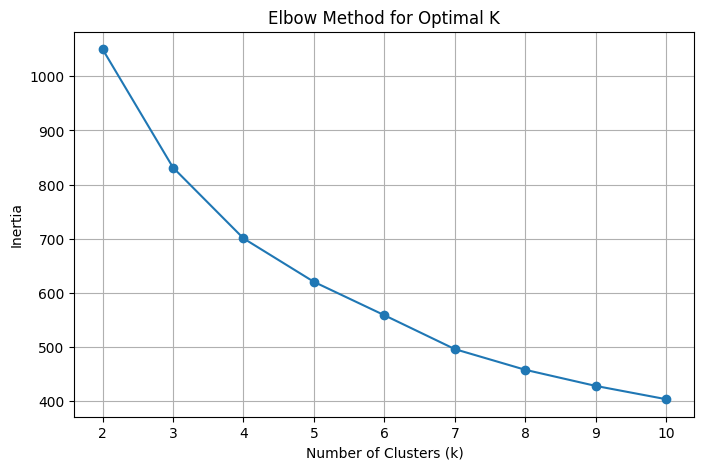

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia_values, marker="o")
print("Inertia Values:", inertia_values)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.xticks(list(k_values))
plt.grid(True)
plt.show()

## Section 9: Train Baseline K-Means Model

Based on the assignment requirement, the baseline cluster count is defined as:

`best_k = 3`

The K-Means model is trained using the scaled country metrics.

In [10]:
best_k = 3

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)

kmeans_labels = kmeans.fit_predict(scaled_features)

data["KMeans_Cluster"] = kmeans_labels

print("K-Means model trained successfully with best_k =", best_k)

data[["country", "KMeans_Cluster"]].head()

K-Means model trained successfully with best_k = 3


,country,KMeans_Cluster
0,Afghanistan,1
1,Albania,2
2,Algeria,2
3,Angola,1
4,Antigua and Barbuda,2


## Section 10: Silhouette Score Evaluation

The `silhouette_score` measures how well-separated and stable the clusters are.

A higher score indicates better-defined clusters.

In [11]:
score = silhouette_score(scaled_features, kmeans_labels)

print("Silhouette Score for K-Means clustering:", round(score, 4))

Silhouette Score for K-Means clustering: 0.2833


## Section 11: Comparative Clustering Using DBSCAN

A secondary clustering model is built using DBSCAN with:

- `eps = 1.5`
- `min_samples = 5`

DBSCAN can detect dense groups and also mark outliers as `-1`.

In [12]:
dbscan = DBSCAN(eps=1.5, min_samples=5)

dbscan_labels = dbscan.fit_predict(scaled_features)

data["DBSCAN_Cluster"] = dbscan_labels

print("DBSCAN clustering completed successfully.")
print("DBSCAN cluster labels and counts:")
print(data["DBSCAN_Cluster"].value_counts().sort_index())
print(
    "DBSCAN Clusters:",
    len(set(dbscan_labels))
    - (1 if -1 in dbscan_labels else 0)
)

print(
    "Noise Points:",
    list(dbscan_labels).count(-1)
)

data[["country", "KMeans_Cluster", "DBSCAN_Cluster"]].head()

DBSCAN clustering completed successfully.
DBSCAN cluster labels and counts:
DBSCAN_Cluster
-1     30
 0    137
Name: count, dtype: int64
DBSCAN Clusters: 1
Noise Points: 30


,country,KMeans_Cluster,DBSCAN_Cluster
0,Afghanistan,1,0
1,Albania,2,0
2,Algeria,2,0
3,Angola,1,-1
4,Antigua and Barbuda,2,0


## Section 12: PCA Dimensionality Reduction

PCA is used to project the high-dimensional country metrics into two dimensions.

This helps visualize the K-Means country segments in a clear 2D scatterplot.

In [13]:
pca = PCA(n_components=2, random_state=42)

pca_components = pca.fit_transform(scaled_features)

pca_df = pd.DataFrame({
    "PCA1": pca_components[:, 0],
    "PCA2": pca_components[:, 1],
    "KMeans_Cluster": kmeans_labels,
    "country": country_names
})

print("Explained variance by PCA components:")
print(pca.explained_variance_ratio_)

pca_df.head()

Explained variance by PCA components:
[0.4595174  0.17181626]


,PCA1,PCA2,KMeans_Cluster,country
0,-2.913025,0.095621,1,Afghanistan
1,0.429911,-0.588156,2,Albania
2,-0.285225,-0.455174,2,Algeria
3,-2.932423,1.695555,1,Angola
4,1.033576,0.136659,2,Antigua and Barbuda


## Section 13: PCA Scatterplot of K-Means Country Segments

This scatterplot shows the countries projected into 2D using PCA.

Each color represents one K-Means cluster.

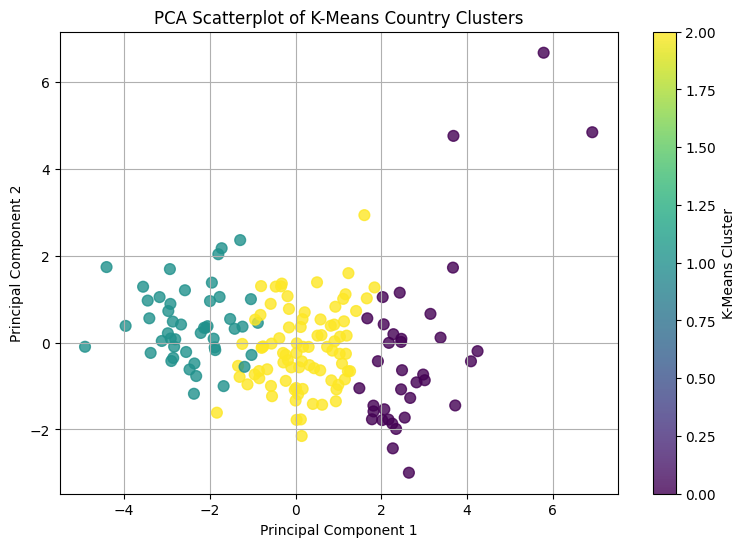

In [14]:
plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    pca_df["PCA1"],
    pca_df["PCA2"],
    c=pca_df["KMeans_Cluster"],
    cmap="viridis",
    s=60,
    alpha=0.8
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Scatterplot of K-Means Country Clusters")
plt.colorbar(scatter, label="K-Means Cluster")
plt.grid(True)
plt.show()

## Section 14: Cluster Summary Table

This summary table helps interpret each cluster based on average socio-economic indicators.

In [15]:
cluster_summary = data.groupby("KMeans_Cluster")[features.columns].mean().round(2)

cluster_summary

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
KMeans_Cluster,,,,,,,,,
0,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
2,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45


## Section 15: Countries in Each Cluster

Display sample countries from each cluster to support socio-economic interpretation.

In [16]:
for cluster in sorted(data["KMeans_Cluster"].unique()):
    print("\nCluster", cluster)
    print(data[data["KMeans_Cluster"] == cluster]["country"].head(15).tolist())


Cluster 0
['Australia', 'Austria', 'Bahrain', 'Belgium', 'Brunei', 'Canada', 'Cyprus', 'Czech Republic', 'Denmark', 'Finland', 'France', 'Germany', 'Greece', 'Iceland', 'Ireland']

Cluster 1
['Afghanistan', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros', 'Congo, Dem. Rep.', 'Congo, Rep.', "Cote d'Ivoire", 'Equatorial Guinea', 'Eritrea']

Cluster 2
['Albania', 'Algeria', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Azerbaijan', 'Bahamas', 'Bangladesh', 'Barbados', 'Belarus', 'Belize', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Brazil']


## Section 16: Socio-Economic Observations

Based on the K-Means cluster summary:

1. **High-mortality cluster:**  
   Cluster 1 represents the highest-risk group because it has the highest average child mortality and fertility rate, along with the lowest life expectancy. These countries need stronger healthcare support, child survival programs, and basic development assistance.

2. **Top-tier economic zone:**  
   Cluster 0 represents the strongest economic group because it has the highest average income and GDP per capita. These countries also show very high life expectancy and low child mortality, indicating stronger healthcare systems and better living standards.

3. **Low-development areas:**  
   Cluster 1 can also be treated as the low-development segment because it has low income, low GDP per capita, high child mortality, and low life expectancy. This shows a clear need for economic development, healthcare investment, and social welfare programs.

4. **Moderate-development countries:**  
   Cluster 2 represents developing or middle-income countries. These countries perform better than the high-mortality group but still have lower income and GDP levels compared to the top-tier economic cluster.

5. **Business and policy insight:**  
   K-Means clustering successfully separates countries into meaningful socio-economic groups. The results can help international organizations prioritize aid, identify countries needing healthcare intervention, and distinguish advanced economies from developing regions.

## Final Conclusion

This notebook successfully completed the required unsupervised learning workflow.

Key outcomes:

- The country metrics dataset was cleaned and prepared correctly.
- Continuous features were scaled using `StandardScaler`.
- The Elbow Method was used to compare cluster ranges from `k = 2` to `k = 10`.
- A baseline K-Means model was trained with `best_k = 3`.
- The Silhouette Score was printed to evaluate cluster stability.
- DBSCAN was used as a secondary comparative clustering method.
- PCA converted the feature space into 2D for visualization.
- Section 16 provided complete socio-economic observations about high-mortality clusters, top-tier economic zones, and low-development areas.